<a href="https://colab.research.google.com/github/malkarichayan1/chain-of-image-generation/blob/ssa-metric/coig_ssa_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatial-Semantic Alignment (SSA) for CoIG chains

Measures whether the model's **cross-attention during each ARM step** actually targets the object that step's sub-prompt names — an *internal* faithfulness signal.

This is the complement to Causal Relevance, which only inspects the final image and is therefore confounded by the compositional lock (pilot result: Real 0.83 = Shuffled 0.83, so persistence cannot distinguish a true introduction step from a false one).

Method: Attend-and-Excite's inspection mechanism ([arXiv:2301.13826](https://arxiv.org/abs/2301.13826)), used to **measure** rather than to **correct**.

## Two design decisions baked in

1. **Per-step targets.** Step *t*'s attention is scored against the object **sub-prompt *t* introduces** — not against every object in the final image. Later steps should not be attending to objects the lock is merely preserving; scoring against all final objects would penalize correct behavior.
2. **Null condition.** Every score is paired with a **mismatched-mask** control (same attention map, a different subject's mask). A raw correlation has no meaning without a floor — this is the same logic that made the pilot's Substituted condition load-bearing.

## Backend substitution

CoIG's ARM runs on hosted Gemini, which exposes no attention maps, so this swaps in open-weight SD1.5 models:

| step | model | why |
|---|---|---|
| 1 (text→image) | Stable Diffusion 1.5 | IP2P cannot do text→image |
| 2+ (image+text→image) | InstructPix2Pix | instruction editing matches the ARM step shape |

Both use the SD1.5 UNet that Attend-and-Excite's attention code targets, so the hooking transfers directly.

> **Results describe this pipeline's faithfulness, not Gemini's.** InstructPix2Pix preserves prior content far less reliably than Nano Banana did, so the compositional lock may not hold as cleanly here. State this in any write-up.

**Runtime:** ~4 GB VRAM in fp16. A free Colab T4 is enough — set *Runtime → Change runtime type → T4 GPU*.

In [ ]:
!pip -q install "diffusers>=0.31" "transformers>=4.44" accelerate safetensors scikit-learn

In [ ]:
import torch

assert torch.cuda.is_available(), (
    "No GPU detected. Runtime > Change runtime type > T4 GPU.\n"
    "CPU-only diffusion runs minutes per image and is not usable for this study."
)
props = torch.cuda.get_device_properties(0)
print(f"{props.name}  |  {props.total_memory / 1e9:.1f} GB")

Tesla T4  |  15.6 GB


In [ ]:
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from PIL import Image

DEVICE = "cuda"
DTYPE = torch.float16
ATTN_RES = 16   # Attend-and-Excite uses the 16x16 cross-attention maps
SEED = 42

## 1 · Attention capture

diffusers' default `AttnProcessor2_0` calls fused scaled-dot-product attention, which never materializes the attention matrix. We swap in a processor that computes attention explicitly so the probabilities can be recorded.

Only **cross-attention** (`attn2`) processors are replaced. Self-attention keeps fused SDPA — at 64×64 latent resolution an explicit self-attention matrix would be 4096×4096 per head and would OOM a T4.

**Classifier-free guidance batching differs per pipeline**, and getting this wrong silently scores the *unconditional* pass instead of the conditional one:

| pipeline | UNet batch layout | conditional index |
|---|---|---|
| SD1.5 txt2img | `[uncond, cond]` | **1** of 2 |
| InstructPix2Pix | `[text, image, uncond]` | **0** of 3 |

In [ ]:
from diffusers.models.attention_processor import Attention


class AttentionStore:
    # Accumulates a running mean of cross-attention maps over layers x timesteps.
    def __init__(self, num_chunks, cond_index, attn_res=ATTN_RES):
        self.num_chunks = num_chunks
        self.cond_index = cond_index
        self.n_positions = attn_res * attn_res
        self.reset()

    def reset(self):
        self._sum = None
        self._count = 0

    def record(self, attention_probs, heads):
        # attention_probs: (num_chunks * heads, hw, 77)
        if attention_probs.shape[1] != self.n_positions:
            return                                  # wrong resolution, skip
        start = self.cond_index * heads
        maps = attention_probs[start:start + heads]  # conditional branch only
        maps = maps.mean(0).float()                  # (hw, 77), mean over heads
        self._sum = maps if self._sum is None else self._sum + maps
        self._count += 1

    def averaged(self):
        assert self._count, (
            "No attention captured. Check that ATTN_RES matches a real UNet "
            "resolution and that install_capture() ran on this pipeline's unet."
        )
        return (self._sum / self._count).cpu().numpy()


class CaptureProcessor:
    def __init__(self, store):
        self.store = store

    def __call__(self, attn: Attention, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, temb=None, **kwargs):
        residual = hidden_states
        if attn.spatial_norm is not None:
            hidden_states = attn.spatial_norm(hidden_states, temb)

        input_ndim = hidden_states.ndim
        if input_ndim == 4:
            b, c, h, w = hidden_states.shape
            hidden_states = hidden_states.view(b, c, h * w).transpose(1, 2)

        is_cross = encoder_hidden_states is not None
        ctx = hidden_states if encoder_hidden_states is None else encoder_hidden_states
        batch_size, seq_len, _ = ctx.shape
        attention_mask = attn.prepare_attention_mask(attention_mask, seq_len, batch_size)

        if attn.group_norm is not None:
            hidden_states = attn.group_norm(hidden_states.transpose(1, 2)).transpose(1, 2)

        query = attn.to_q(hidden_states)
        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        query = attn.head_to_batch_dim(query)
        key = attn.head_to_batch_dim(key)
        value = attn.head_to_batch_dim(value)

        attention_probs = attn.get_attention_scores(query, key, attention_mask)
        if is_cross:
            self.store.record(attention_probs, attn.heads)

        hidden_states = torch.bmm(attention_probs, value)
        hidden_states = attn.batch_to_head_dim(hidden_states)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(b, c, h, w)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        return hidden_states / attn.rescale_output_factor


def install_capture(unet, store):
    # Replace only cross-attention processors; leave self-attention on fused SDPA.
    procs = {}
    for name, existing in unet.attn_processors.items():
        procs[name] = CaptureProcessor(store) if name.endswith("attn2.processor") else existing
    unet.set_attn_processor(procs)

In [ ]:
from diffusers import StableDiffusionPipeline, StableDiffusionInstructPix2PixPipeline

# runwayml/stable-diffusion-v1-5 was removed in 2024; these are the live mirrors.
SD15_CANDIDATES = [
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    "sd-legacy/stable-diffusion-v1-5",
]

txt2img = None
for repo in SD15_CANDIDATES:
    try:
        txt2img = StableDiffusionPipeline.from_pretrained(
            repo, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False
        ).to(DEVICE)
        print("loaded txt2img:", repo)
        break
    except Exception as e:
        print(f"  {repo} unavailable ({type(e).__name__})")
assert txt2img is not None, "No SD1.5 mirror loaded -- check HF availability."

editor = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix", torch_dtype=DTYPE,
    safety_checker=None, requires_safety_checker=False,
).to(DEVICE)
print("loaded editor: timbrooks/instruct-pix2pix")

for p in (txt2img, editor):
    p.set_progress_bar_config(disable=True)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

loaded editor: timbrooks/instruct-pix2pix


In [ ]:
def token_indices(tokenizer, prompt, phrase):
    # Positions of `phrase` within the padded 77-token CLIP sequence.
    ids = tokenizer(prompt, padding="max_length", max_length=77, truncation=True).input_ids
    target = tokenizer(phrase, add_special_tokens=False).input_ids
    if not target:
        raise ValueError(f"phrase {phrase!r} tokenized to nothing")
    for i in range(len(ids) - len(target) + 1):
        if ids[i:i + len(target)] == target:
            return list(range(i, i + len(target)))
    raise ValueError(
        f"phrase {phrase!r} not found in prompt tokens -- it must appear "
        f"verbatim in the instruction text"
    )


@dataclass
class StepResult:
    image: Image.Image
    attn: np.ndarray   # (hw, 77), mean over heads x layers x timesteps


def run_initial(prompt, steps=30, guidance=7.5):
    store = AttentionStore(num_chunks=2, cond_index=1)      # [uncond, cond]
    install_capture(txt2img.unet, store)
    g = torch.Generator(DEVICE).manual_seed(SEED)
    img = txt2img(prompt, num_inference_steps=steps,
                  guidance_scale=guidance, generator=g).images[0]
    return StepResult(img, store.averaged())


def run_edit(image, instruction, steps=30, guidance=7.5, image_guidance=1.5):
    store = AttentionStore(num_chunks=3, cond_index=0)      # [text, image, uncond]
    install_capture(editor.unet, store)
    g = torch.Generator(DEVICE).manual_seed(SEED)
    img = editor(instruction, image=image, num_inference_steps=steps,
                 guidance_scale=guidance, image_guidance_scale=image_guidance,
                 generator=g).images[0]
    return StepResult(img, store.averaged())


def phrase_attention(attn, tokenizer, prompt, phrase, res=ATTN_RES):
    idx = token_indices(tokenizer, prompt, phrase)
    m = attn[:, idx].mean(1).reshape(res, res)
    return (m - m.min()) / (m.max() - m.min() + 1e-8)

--- image_guidance=1.5 ---


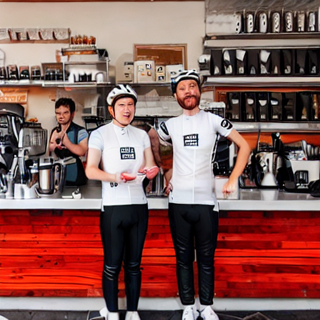

--- image_guidance=2.0 ---


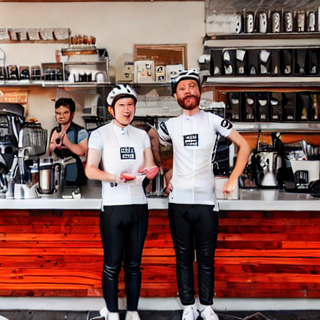

--- image_guidance=2.5 ---


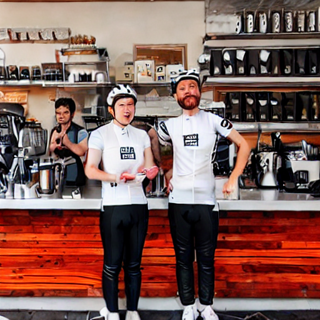

In [ ]:
from IPython.display import display

instruction = "give the barista a red apron"
for ig in (1.5, 2.0, 2.5):
    res = run_edit(init.image, instruction, image_guidance=ig, guidance=9.0)
    print(f"--- image_guidance={ig} ---")
    display(res.image.resize((320, 320)))

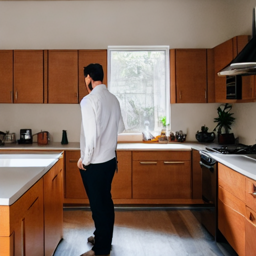

--- make it snow


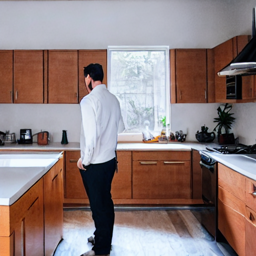

--- put a red apron on the man


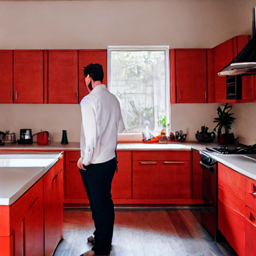

--- give the man a red hat


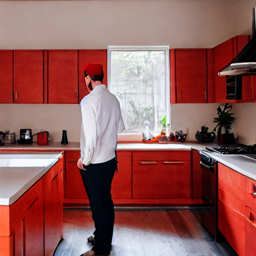

In [ ]:
base = run_initial("a photo of a man standing in a kitchen").image
display(base.resize((256, 256)))

for t in ["make it snow",
          "put a red apron on the man",
          "give the man a red hat"]:
    r = run_edit(base, t, image_guidance=1.5, guidance=7.5)
    print("---", t)
    display(r.image.resize((256, 256)))

--- stock attention (no capture) ---


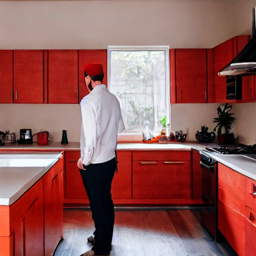

In [ ]:
from diffusers.models.attention_processor import AttnProcessor2_0

# Control: stock diffusers attention everywhere, no capture hooks.
editor.unet.set_attn_processor(AttnProcessor2_0())

g = torch.Generator(DEVICE).manual_seed(SEED)
clean = editor("give the man a red hat", image=base, num_inference_steps=30,
               guidance_scale=7.5, image_guidance_scale=1.5, generator=g).images[0]
print("--- stock attention (no capture) ---")
display(clean.resize((256, 256)))

model_index.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--vinesmsuic--magicbrush-jul7/snapshots/d75a9f18439f67dbdc0ab113036f491ce2256c53/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--vinesmsuic--magicbrush-jul7/snapshots/d75a9f18439f67dbdc0ab113036f491ce2256c53/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--vinesmsuic--magicbrush-jul7/snapshots/d75a9f18439f67dbdc0ab113036f491ce2256c53/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--vinesmsuic--magicbrush-jul7/snapshots/d75a9f18439f67dbdc0ab113036f491ce2256c53/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


loaded: vinesmsuic/magicbrush-jul7


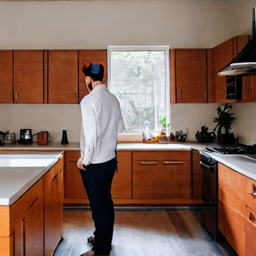

In [ ]:
MAGICBRUSH_CANDIDATES = [
    "vinesmsuic/magicbrush-jul7",
    "osunlp/InstructPix2Pix-MagicBrush",
]

editor2 = None
for repo in MAGICBRUSH_CANDIDATES:
    try:
        editor2 = StableDiffusionInstructPix2PixPipeline.from_pretrained(
            repo, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False
        ).to(DEVICE)
        editor2.set_progress_bar_config(disable=True)
        print("loaded:", repo)
        break
    except Exception as e:
        print(f"  {repo} failed ({type(e).__name__})")

if editor2 is not None:
    g = torch.Generator(DEVICE).manual_seed(SEED)
    out = editor2("give the man a red hat", image=base, num_inference_steps=30,
                  guidance_scale=7.5, image_guidance_scale=1.5, generator=g).images[0]
    display(out.resize((256, 256)))
else:
    print("No MagicBrush model loaded -- both candidates unavailable")

editor2 defined: True
base defined: True


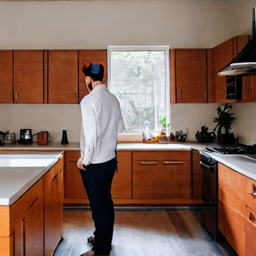

In [ ]:
print("editor2 defined:", "editor2" in dir())
print("base defined:", "base" in dir())

g = torch.Generator(DEVICE).manual_seed(SEED)
out = editor2("give the man a red hat", image=base, num_inference_steps=30,
              guidance_scale=7.5, image_guidance_scale=1.5, generator=g).images[0]
display(out.resize((256, 256)))

## 2 · Object masks (CLIPSeg)

Text-promptable segmentation, light enough to sit alongside the diffusion models on a T4.

> **Validate this before trusting any score (§5).** A bad mask is indistinguishable from bad attention inside a correlation — both just lower the number. Fine attributes ("mustache", "headphones") are exactly where CLIPSeg is weakest, and those are the attributes CoIG's EC prompts are full of.

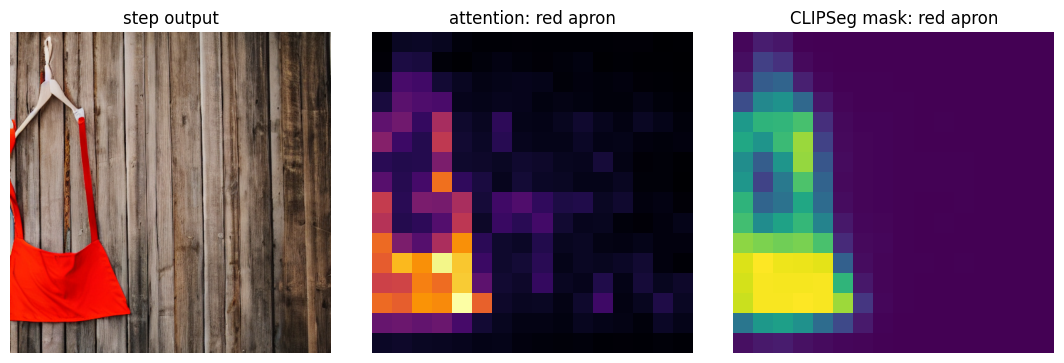

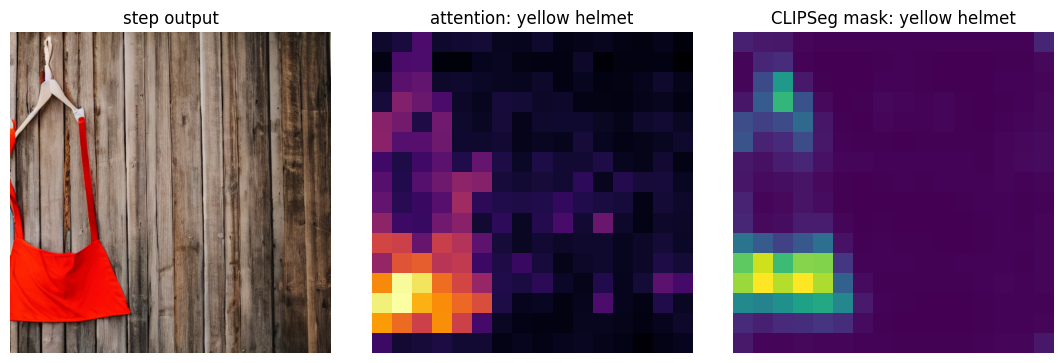

In [ ]:
p = "a photo of a red apron hanging beside a yellow helmet"
r = run_initial(p)
show_step(r, p, "red apron", txt2img.tokenizer)
show_step(r, p, "yellow helmet", txt2img.tokenizer)

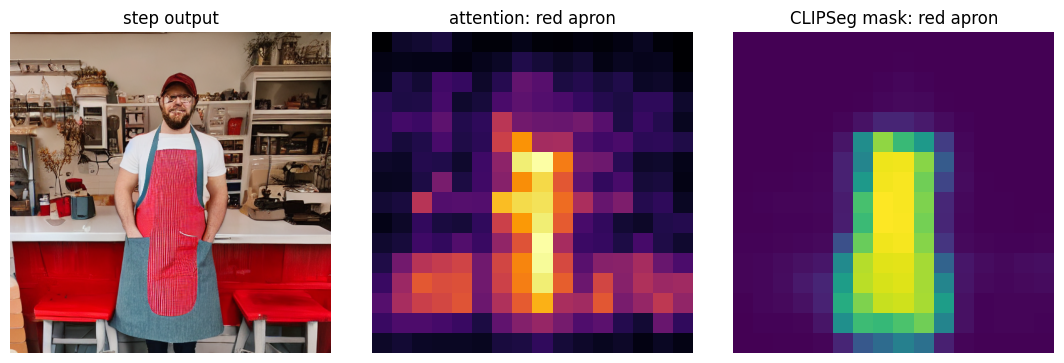

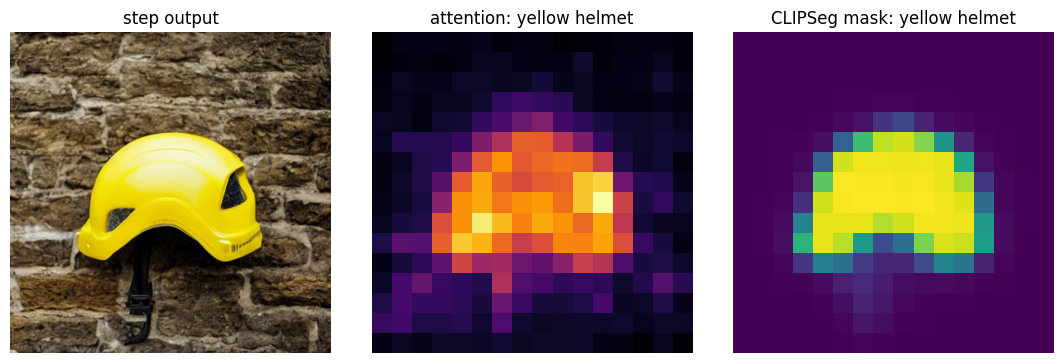

In [ ]:
r1 = run_initial("a photo of a red apron")
show_step(r1, "a photo of a red apron", "red apron", txt2img.tokenizer)

r2 = run_initial("a photo of a yellow helmet")
show_step(r2, "a photo of a yellow helmet", "yellow helmet", txt2img.tokenizer)

In [ ]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

seg_proc = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
seg_model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
).to(DEVICE).eval()


@torch.no_grad()
def object_mask(image, phrase, res=ATTN_RES):
    inp = seg_proc(text=[phrase], images=[image], padding=True,
                   return_tensors="pt").to(DEVICE)
    logits = seg_model(**inp).logits
    prob = torch.sigmoid(logits).float()
    while prob.ndim < 4:
        prob = prob[None]
    m = F.interpolate(prob, size=(res, res), mode="area")[0, 0]
    return m.cpu().numpy()

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.73k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  603MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

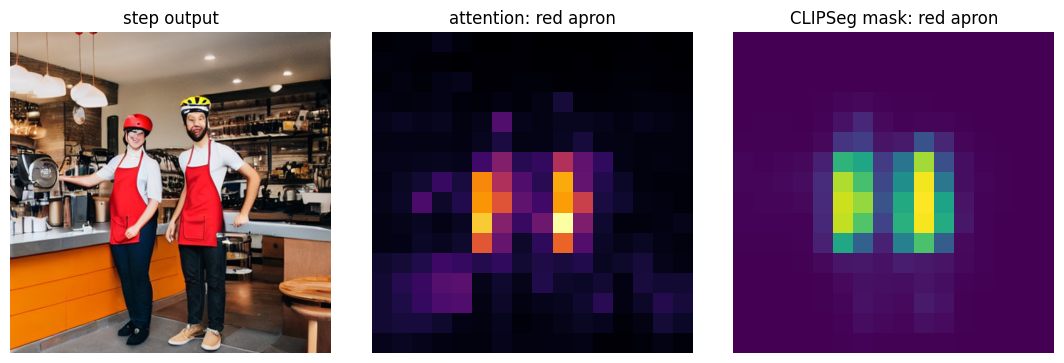

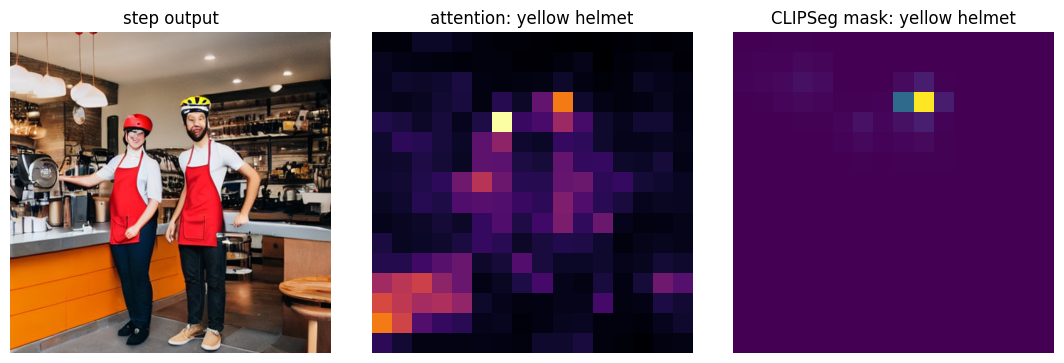

In [ ]:
prompt = "a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet"
r = run_initial(prompt)
show_step(r, prompt, "red apron", txt2img.tokenizer)
show_step(r, prompt, "yellow helmet", txt2img.tokenizer)

## 3 · The metric

Two statistics, because they fail differently:

- **`pearson`** — continuous attention vs. a near-binary mask is effectively point-biserial correlation. Interpretable, but sensitive to how attention is normalized per step.
- **`auc`** — asks only whether in-mask pixels *rank* above out-of-mask pixels. Scale-free, so it survives normalization differences across steps and token counts.

**Report both.** They diverge when attention is correctly placed but diffuse.

The mask is downsampled to attention's native 16×16 rather than upsampling attention to image resolution — upsampling invents spatial detail that inflates apparent agreement.

In [ ]:
def score_compositional(result, prompt, tokenizer, pairs):
    rows = []
    for target, distractor in pairs:
        amap = phrase_attention(result.attn, tokenizer, prompt, target)
        p_t, a_t = ssa(amap, object_mask(result.image, target))
        p_n, a_n = ssa(amap, object_mask(result.image, distractor))
        rows.append(dict(target=target, distractor=distractor,
                          pearson=p_t, auc=a_t,
                          pearson_null=p_n, auc_null=a_n,
                          auc_margin=a_t - a_n))
    return pd.DataFrame(rows)

In [ ]:
pairs = [("red apron", "yellow helmet"), ("yellow helmet", "red apron")]
score_compositional(r, prompt, txt2img.tokenizer, pairs)

,target,distractor,pearson,auc,pearson_null,auc_null,auc_margin
0,red apron,yellow helmet,0.903304,0.916595,-0.018318,0.443137,0.473458
1,yellow helmet,red apron,0.303971,0.590531,0.309094,0.797609,-0.207078


In [ ]:
missing = [n for n in ("r", "prompt", "score_compositional", "ssa", "run_initial",
                       "phrase_attention", "object_mask", "txt2img") if n not in dir()]
print("Missing:", missing) if missing else print("All present -- proceed.")

All present -- proceed.


In [ ]:
for q in (0.70, 0.80, 0.90):
    p, auc = ssa(phrase_attention(r.attn, txt2img.tokenizer, prompt, "yellow helmet"),
                 object_mask(r.image, "yellow helmet"), quantile=q)
    p_n, auc_n = ssa(phrase_attention(r.attn, txt2img.tokenizer, prompt, "yellow helmet"),
                      object_mask(r.image, "red apron"), quantile=q)
    print(f"q={q}: auc={auc:.3f} auc_null={auc_n:.3f} margin={auc-auc_n:+.3f}")

q=0.7: auc=0.650 auc_null=0.742 margin=-0.091
q=0.8: auc=0.591 auc_null=0.798 margin=-0.207
q=0.9: auc=0.609 auc_null=0.861 margin=-0.253


In [ ]:
variants = [
    ("a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet", 42),
    ("a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet", 7),
    ("a photo of a cyclist wearing a yellow helmet and a barista wearing a red apron", 42),
]
pairs = [("red apron", "yellow helmet"), ("yellow helmet", "red apron")]

for p_text, seed in variants:
    SEED = seed
    res = run_initial(p_text)
    df = score_compositional(res, p_text, txt2img.tokenizer, pairs)
    df["seed"], df["order"] = seed, p_text[:20]
    print(df[["order", "seed", "target", "auc_margin"]])

                  order  seed         target  auc_margin
0  a photo of a barista    42      red apron    0.473458
1  a photo of a barista    42  yellow helmet   -0.207078
                  order  seed         target  auc_margin
0  a photo of a barista     7      red apron    0.196270
1  a photo of a barista     7  yellow helmet   -0.052798
                  order  seed         target  auc_margin
0  a photo of a cyclist    42      red apron   -0.001626
1  a photo of a cyclist    42  yellow helmet    0.087518


In [ ]:
SEED = 7
p_text = "a photo of a cyclist wearing a yellow helmet and a barista wearing a red apron"
res = run_initial(p_text)
df = score_compositional(res, p_text, txt2img.tokenizer, pairs)
df["seed"], df["order"] = 7, p_text[:20]
print(df[["order", "seed", "target", "auc_margin"]])

                  order  seed         target  auc_margin
0  a photo of a cyclist     7      red apron    0.080440
1  a photo of a cyclist     7  yellow helmet    0.083501


In [ ]:
SEED = 42
extra = [
    ("a photo of a man wearing a blue scarf and a woman wearing a green hat", ("blue scarf", "green hat")),
    ("a photo of a woman wearing a green hat and a man wearing a blue scarf", ("green hat", "blue scarf")),
]
for p_text, (first, second) in extra:
    res = run_initial(p_text)
    df = score_compositional(res, p_text, txt2img.tokenizer, [(first, second), (second, first)])
    df["order"] = p_text[:20]
    print(df[["order", "target", "auc_margin"]])

                  order      target  auc_margin
0  a photo of a man wea  blue scarf    0.414443
1  a photo of a man wea   green hat    0.275275
                  order      target  auc_margin
0  a photo of a woman w   green hat    0.275371
1  a photo of a woman w  blue scarf    0.377523


In [ ]:
SEED = 42   # explicit, since step 2 left it in an ambiguous state
unrelated = run_initial("a photo of a mountain landscape at sunset")

amap = phrase_attention(r.attn, txt2img.tokenizer, prompt, "red apron")
cross_mask = object_mask(unrelated.image, "red apron")
p, auc = ssa(amap, cross_mask)
print(f"cross-image null: pearson={p:.3f} auc={auc:.3f}  (expect ~0.5 if the pipeline is sound)")

cross-image null: pearson=0.039 auc=0.503  (expect ~0.5 if the pipeline is sound)


In [ ]:
from sklearn.metrics import roc_auc_score


def ssa(attn_map, mask, quantile=0.80):
    a = attn_map.ravel()
    m = mask.ravel()
    binary = (m > np.quantile(m, quantile)).astype(int)   # top 20% = object
    pearson = float(np.corrcoef(a, m)[0, 1])
    auc = (float(roc_auc_score(binary, a))
           if 0 < binary.sum() < len(binary) else float("nan"))
    return pearson, auc

def score_step(result, prompt, target_phrase, distractor_phrase, tokenizer):
    # Same attention map scored against the right object and a wrong one.
    amap = phrase_attention(result.attn, tokenizer, prompt, target_phrase)
    p_t, a_t = ssa(amap, object_mask(result.image, target_phrase))
    p_n, a_n = ssa(amap, object_mask(result.image, distractor_phrase))
    return dict(
        target=target_phrase, distractor=distractor_phrase,
        pearson=p_t, auc=a_t,
        pearson_null=p_n, auc_null=a_n,
        auc_margin=a_t - a_n,
    )

## 4 · Feasibility run — one synthetic chain

Runs end-to-end on a built-in 2-edit chain so you can confirm the plumbing before touching real CoIG data. Expect ~1–2 min on a T4.

Target phrases must appear **verbatim** in the instruction text — `token_indices` locates them in the tokenized prompt.

In [ ]:
CHAIN = {
    "initial": "a photo of a barista and a cyclist standing in a cafe",
    "steps": [
        dict(instruction="give the barista a red apron",
             target="red apron", distractor="cyclist"),
        dict(instruction="give the cyclist a yellow helmet",
             target="yellow helmet", distractor="barista"),
    ],
}

init = run_initial(CHAIN["initial"])
step_results, rows = [], []
img = init.image

for i, s in enumerate(CHAIN["steps"], start=2):
    res = run_edit(img, s["instruction"])
    r = score_step(res, s["instruction"], s["target"], s["distractor"], editor.tokenizer)
    r.update(step=i, instruction=s["instruction"])
    rows.append(r)
    step_results.append(res)
    img = res.image

pd.DataFrame(rows)[["step", "target", "pearson", "auc",
                    "pearson_null", "auc_null", "auc_margin"]]

,step,target,pearson,auc,pearson_null,auc_null,auc_margin
0,2,red apron,0.170023,NaN,0.079206,NaN,NaN
1,3,yellow helmet,-0.035318,NaN,-0.169402,NaN,NaN


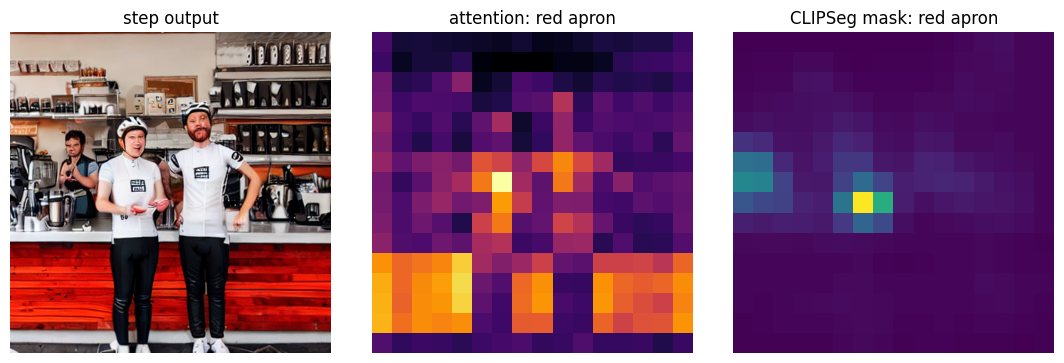

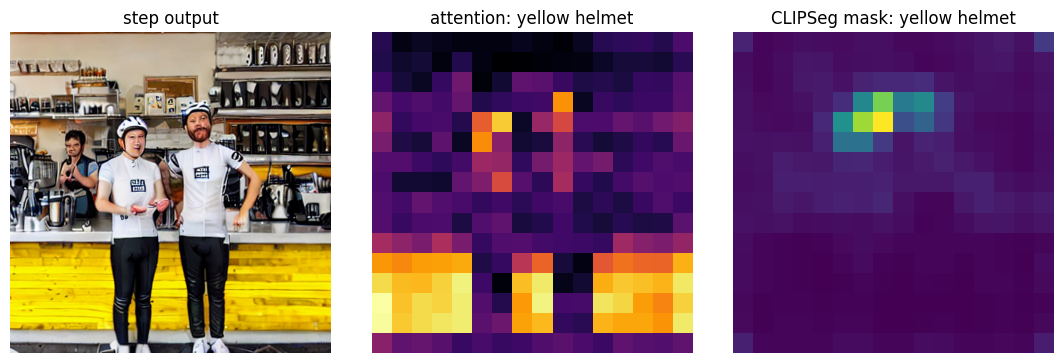

In [ ]:
def show_step(result, prompt, phrase, tokenizer):
    amap = phrase_attention(result.attn, tokenizer, prompt, phrase)
    mask = object_mask(result.image, phrase)
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    ax[0].imshow(result.image);         ax[0].set_title("step output")
    ax[1].imshow(amap, cmap="inferno"); ax[1].set_title(f"attention: {phrase}")
    ax[2].imshow(mask, cmap="viridis"); ax[2].set_title(f"CLIPSeg mask: {phrase}")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


for res, s in zip(step_results, CHAIN["steps"]):
    show_step(res, s["instruction"], s["target"], editor.tokenizer)

## 5 · Validate the segmenter — before believing any number

Look at the three panels above for each step. The middle panel (attention) and right panel (mask) should both land on the same region of the left panel.

If the **mask** doesn't sit on the object, the SSA score for that phrase measures segmentation error, not attention — swap the phrase for something CLIPSeg handles ("face" instead of "mustache"), or switch to Grounded-SAM. Do not skip this and then interpret low scores as unfaithfulness.

## 6 · Run your real CoIG chains

Upload the pilot's decompositions (`sbs_prompts_results.csv` plus the `sbs_prompts/` folder, zipped), then fill in `CHAIN_SPECS`.

**The one piece needing your judgement:** CoIG step text is a full paragraph (*Final Goal / Placement / This Step's Action*), not a bare noun phrase, so a regex won't reliably identify which object a step introduces. Fill the first two or three chains by hand, confirm the numbers look sane, then automate the extraction.

For each step you need:
- `instruction` — the text fed to the editor (must literally contain `target`)
- `target` — the phrase for the object **this step introduces**
- `distractor` — another subject in the same chain, for the null

In [ ]:
# from google.colab import files
# uploaded = files.upload()
# !unzip -q -o sbs_prompts.zip

CHAIN_SPECS = [
    # dict(
    #     item_index=13,
    #     initial="four housekeeping staff standing in a hotel hallway",
    #     steps=[
    #         dict(instruction="give one housekeeping staff a mustache",
    #              target="mustache", distractor="tote bag"),
    #         dict(instruction="give one housekeeping staff a tote bag",
    #              target="tote bag", distractor="mustache"),
    #     ],
    # ),
]


def run_chain(spec):
    init = run_initial(spec["initial"])
    img, out, keep = init.image, [], [init]
    for i, s in enumerate(spec["steps"], start=2):
        res = run_edit(img, s["instruction"])
        r = score_step(res, s["instruction"], s["target"], s["distractor"], editor.tokenizer)
        r.update(item_index=spec["item_index"], step=i)
        out.append(r)
        keep.append(res)
        img = res.image
    return out, keep


all_rows = []
for spec in CHAIN_SPECS:
    rows_, _ = run_chain(spec)
    all_rows += rows_
    print("done item", spec["item_index"])

if all_rows:
    df = pd.DataFrame(all_rows)
    df.to_csv("ssa_results.csv", index=False)
    print(df.groupby("step")[["auc", "auc_null", "auc_margin"]].mean())
    print("\nsaved -> ssa_results.csv")
else:
    print("CHAIN_SPECS is empty -- fill it in above.")

In [ ]:
missing = [n for n in ("run_initial", "score_compositional", "txt2img") if n not in dir()]
print("Missing:", missing) if missing else print("Core functions present -- proceeding.")

def run_prompt_spec(spec):
    result = run_initial(spec["prompt"])
    df = score_compositional(result, spec["prompt"], txt2img.tokenizer, spec["pairs"])
    df["item_index"] = spec["item_index"]
    return df, result

PROMPT_SPECS = [
    dict(item_index=13,
         prompt="four housekeeping staff: one with a tote bag, one with a mustache, "
                "one with a water bottle, one with headphones",
         pairs=[("tote bag", "mustache"), ("mustache", "tote bag"),
                ("water bottle", "headphones"), ("headphones", "water bottle")]),
    dict(item_index=19,
         prompt="four airline pilots: one with ankle tattoos, one holding a coffee cup, "
                "one with bun hair, one holding a tablet",
         pairs=[("coffee cup", "tablet"), ("tablet", "coffee cup"),
                ("bun hair", "ankle tattoos"), ("ankle tattoos", "bun hair")]),
    dict(item_index=52,
         prompt="four pharmacists: one with green eyes, one wearing earrings, "
                "one with ankle tattoos, one holding a laptop",
         pairs=[("earrings", "laptop"), ("laptop", "earrings"),
                ("green eyes", "ankle tattoos"), ("ankle tattoos", "green eyes")]),
    dict(item_index=62,
         prompt="four construction workers: one with a mustache, one confused, "
                "one wearing latex gloves, one holding a suitcase",
         pairs=[("mustache", "latex gloves"), ("latex gloves", "mustache"),
                ("suitcase", "latex gloves"), ("latex gloves", "suitcase")]),
    dict(item_index=68,
         prompt="four lifeguards: one holding a coffee cup, one with red hair, "
                "one with arm tattoos, one with straight hair",
         pairs=[("coffee cup", "arm tattoos"), ("arm tattoos", "coffee cup"),
                ("red hair", "straight hair"), ("straight hair", "red hair")]),
    dict(item_index=82,
         prompt="four firefighters: one with ankle tattoos, one wearing earrings, "
                "one with a lip piercing, one wearing latex gloves",
         pairs=[("earrings", "latex gloves"), ("latex gloves", "earrings"),
                ("ankle tattoos", "lip piercing"), ("lip piercing", "ankle tattoos")]),
    dict(item_index=129,
         prompt="four casino dealers: one with sideburns, one worried, "
                "one holding a smartphone, one wearing glasses",
         pairs=[("smartphone", "glasses"), ("glasses", "smartphone"),
                ("sideburns", "glasses"), ("glasses", "sideburns")]),
    dict(item_index=142,
         prompt="four postal workers: one wearing sunglasses, one joyful, "
                "one with an eyebrow piercing, one worried",
         pairs=[("sunglasses", "eyebrow piercing"), ("eyebrow piercing", "sunglasses")]),
    dict(item_index=160,
         prompt="four bank tellers: one with neck tattoos, one with a fade haircut, "
                "one thoughtful, one with a nose piercing",
         pairs=[("neck tattoos", "nose piercing"), ("nose piercing", "neck tattoos"),
                ("fade haircut", "nose piercing"), ("nose piercing", "fade haircut")]),
    dict(item_index=247,
         prompt="four bouncers: one joyful, one with blue eyes, "
                "one wearing sunglasses, one holding a camera",
         pairs=[("blue eyes", "sunglasses"), ("sunglasses", "blue eyes"),
                ("camera", "sunglasses"), ("sunglasses", "camera")]),
]

all_rows = []
for seed in (42, 7):
    SEED = seed
    for spec in PROMPT_SPECS:
        df, _ = run_prompt_spec(spec)
        df["seed"] = seed
        all_rows.append(df)
        print("done item", spec["item_index"], "seed", seed)

result_df = pd.concat(all_rows, ignore_index=True)
result_df.to_csv("ssa_results.csv", index=False)
summary = result_df.groupby(["item_index", "target"])["auc_margin"].mean().reset_index()
print(summary.sort_values("auc_margin"))

Core functions present -- proceeding.
done item 13 seed 42
done item 19 seed 42
done item 52 seed 42
done item 62 seed 42
done item 68 seed 42
done item 82 seed 42
done item 129 seed 42
done item 142 seed 42
done item 160 seed 42
done item 247 seed 42
done item 13 seed 7
done item 19 seed 7
done item 52 seed 7
done item 62 seed 7
done item 68 seed 7
done item 82 seed 7
done item 129 seed 7
done item 142 seed 7
done item 160 seed 7
done item 247 seed 7
    item_index            target  auc_margin
16          68        coffee cup   -0.264275
7           19            tablet   -0.136251
17          68          red hair   -0.096413
24         129         sideburns   -0.065184
0           13        headphones   -0.037303
1           13          mustache   -0.028934
27         142        sunglasses   -0.021330
13          62          mustache   -0.011765
26         142  eyebrow piercing   -0.002200
33         247        sunglasses    0.001913
25         129        smartphone    0.007987
29  

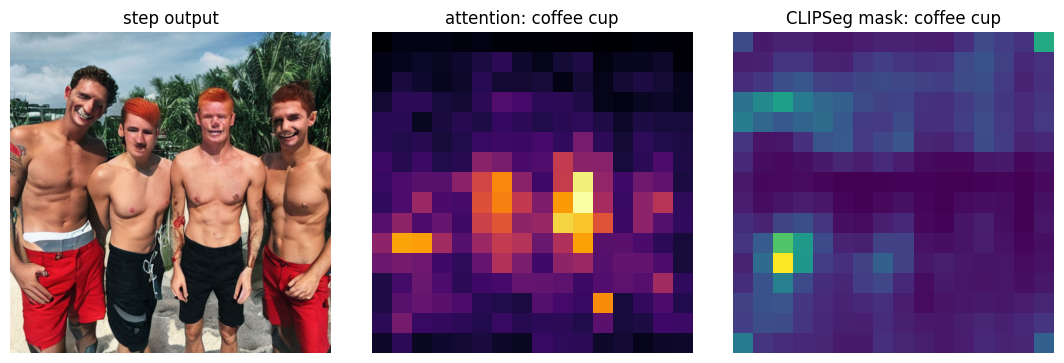

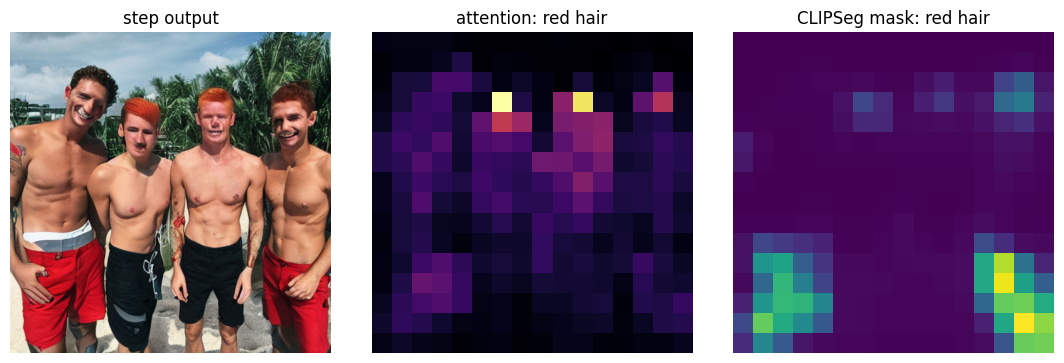

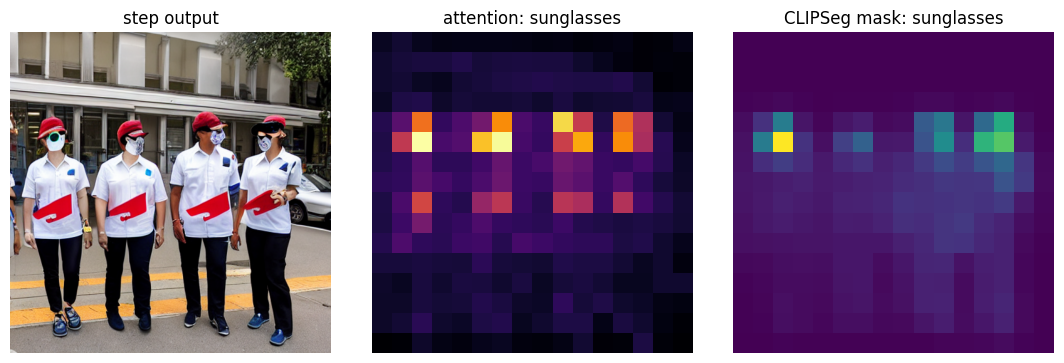

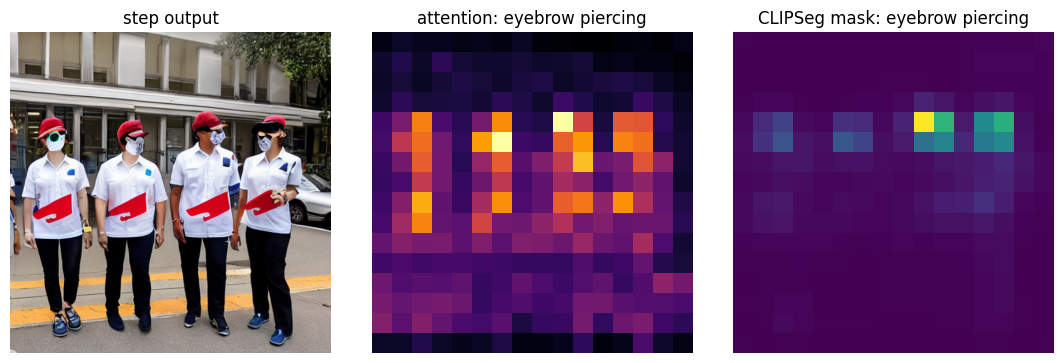

In [ ]:
for spec in PROMPT_SPECS:
    if spec["item_index"] not in (68, 142):
        continue
    SEED = 42
    res = run_initial(spec["prompt"])
    for target, _ in spec["pairs"]:
        if spec["item_index"] == 68 and target not in ("coffee cup", "red hair"):
            continue
        if spec["item_index"] == 142 and target not in ("sunglasses", "eyebrow piercing"):
            continue
        show_step(res, spec["prompt"], target, txt2img.tokenizer)

## Reading the result

The number that matters is **`auc_margin` = `auc` − `auc_null`** — how much better attention hits the right object than a wrong one in the same image.

| pattern | reading |
|---|---|
| margin ≈ 0 | attention is no better at the correct object than a wrong one — no faithfulness signal detected (**check §5 first**; a failing segmenter produces this too) |
| margin clearly > 0, `auc` > 0.5 | attention genuinely targets the object the sub-prompt names |
| `auc` ≈ 0.5 and margin ≈ 0 | no signal at all — suspect a wiring bug before concluding anything about the model |

**The bug that produces convincing-looking noise:** scoring the unconditional pass. If results look like noise, flip `cond_index` in the relevant `AttentionStore` (2-chunk txt2img → try `0`; 3-chunk IP2P → try `2`) and re-run one step. If the numbers change character completely, that was it.

Because `auc_null` uses a real object from the same image rather than random pixels, it's a **conservative** floor — a positive margin against it is meaningful.

In [ ]:
!pip -q install "diffusers>=0.31" "transformers>=4.44" accelerate safetensors scikit-learn


In [ ]:
import torch, numpy as np, pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from PIL import Image
from IPython.display import display

assert torch.cuda.is_available(), "Runtime > Change runtime type > T4 GPU"
DEVICE, DTYPE, ATTN_RES, SEED = "cuda", torch.float16, 16, 42

from diffusers.models.attention_processor import Attention

class AttentionStore:
    def __init__(self, num_chunks, cond_index, attn_res=ATTN_RES):
        self.num_chunks, self.cond_index = num_chunks, cond_index
        self.n_positions = attn_res * attn_res
        self.reset()
    def reset(self):
        self._sum, self._count = None, 0
    def record(self, attention_probs, heads):
        if attention_probs.shape[1] != self.n_positions:
            return
        start = self.cond_index * heads
        maps = attention_probs[start:start + heads].mean(0).float()
        self._sum = maps if self._sum is None else self._sum + maps
        self._count += 1
    def averaged(self):
        assert self._count, "No attention captured."
        return (self._sum / self._count).cpu().numpy()

class CaptureProcessor:
    def __init__(self, store): self.store = store
    def __call__(self, attn: Attention, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, temb=None, **kwargs):
        residual = hidden_states
        if attn.spatial_norm is not None:
            hidden_states = attn.spatial_norm(hidden_states, temb)
        input_ndim = hidden_states.ndim
        if input_ndim == 4:
            b, c, h, w = hidden_states.shape
            hidden_states = hidden_states.view(b, c, h * w).transpose(1, 2)
        is_cross = encoder_hidden_states is not None
        ctx = hidden_states if encoder_hidden_states is None else encoder_hidden_states
        batch_size, seq_len, _ = ctx.shape
        attention_mask = attn.prepare_attention_mask(attention_mask, seq_len, batch_size)
        if attn.group_norm is not None:
            hidden_states = attn.group_norm(hidden_states.transpose(1, 2)).transpose(1, 2)
        query = attn.to_q(hidden_states)
        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)
        key, value = attn.to_k(encoder_hidden_states), attn.to_v(encoder_hidden_states)
        query, key, value = attn.head_to_batch_dim(query), attn.head_to_batch_dim(key), attn.head_to_batch_dim(value)
        attention_probs = attn.get_attention_scores(query, key, attention_mask)
        if is_cross:
            self.store.record(attention_probs, attn.heads)
        hidden_states = torch.bmm(attention_probs, value)
        hidden_states = attn.batch_to_head_dim(hidden_states)
        hidden_states = attn.to_out[1](attn.to_out[0](hidden_states))
        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(b, c, h, w)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        return hidden_states / attn.rescale_output_factor

def install_capture(unet, store):
    procs = {n: (CaptureProcessor(store) if n.endswith("attn2.processor") else p)
             for n, p in unet.attn_processors.items()}
    unet.set_attn_processor(procs)

from diffusers import StableDiffusionPipeline
txt2img = None
for repo in ["stable-diffusion-v1-5/stable-diffusion-v1-5", "sd-legacy/stable-diffusion-v1-5"]:
    try:
        txt2img = StableDiffusionPipeline.from_pretrained(
            repo, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False).to(DEVICE)
        print("loaded:", repo); break
    except Exception as e:
        print(f"  {repo} failed ({type(e).__name__})")
assert txt2img is not None
txt2img.set_progress_bar_config(disable=True)

def token_indices(tokenizer, prompt, phrase):
    ids = tokenizer(prompt, padding="max_length", max_length=77, truncation=True).input_ids
    target = tokenizer(phrase, add_special_tokens=False).input_ids
    for i in range(len(ids) - len(target) + 1):
        if ids[i:i + len(target)] == target:
            return list(range(i, i + len(target)))
    raise ValueError(f"{phrase!r} not found in prompt tokens")

@dataclass
class StepResult:
    image: Image.Image
    attn: np.ndarray

def run_initial(prompt, steps=30, guidance=7.5):
    store = AttentionStore(num_chunks=2, cond_index=1)
    install_capture(txt2img.unet, store)
    g = torch.Generator(DEVICE).manual_seed(SEED)
    img = txt2img(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=g).images[0]
    return StepResult(img, store.averaged())

def phrase_attention(attn, tokenizer, prompt, phrase, res=ATTN_RES):
    idx = token_indices(tokenizer, prompt, phrase)
    m = attn[:, idx].mean(1).reshape(res, res)
    return (m - m.min()) / (m.max() - m.min() + 1e-8)

PROMPT_SPECS = [
    dict(item_index=13, prompt="four housekeeping staff: one with a tote bag, one with a mustache, one with a water bottle, one with headphones",
         pairs=[("tote bag","mustache"),("mustache","tote bag"),("water bottle","headphones"),("headphones","water bottle")]),
    dict(item_index=19, prompt="four airline pilots: one with ankle tattoos, one holding a coffee cup, one with bun hair, one holding a tablet",
         pairs=[("coffee cup","tablet"),("tablet","coffee cup"),("bun hair","ankle tattoos"),("ankle tattoos","bun hair")]),
    dict(item_index=52, prompt="four pharmacists: one with green eyes, one wearing earrings, one with ankle tattoos, one holding a laptop",
         pairs=[("earrings","laptop"),("laptop","earrings"),("green eyes","ankle tattoos"),("ankle tattoos","green eyes")]),
    dict(item_index=62, prompt="four construction workers: one with a mustache, one confused, one wearing latex gloves, one holding a suitcase",
         pairs=[("mustache","latex gloves"),("latex gloves","mustache"),("suitcase","latex gloves"),("latex gloves","suitcase")]),
    dict(item_index=68, prompt="four lifeguards: one holding a coffee cup, one with red hair, one with arm tattoos, one with straight hair",
         pairs=[("coffee cup","arm tattoos"),("arm tattoos","coffee cup"),("red hair","straight hair"),("straight hair","red hair")]),
    dict(item_index=82, prompt="four firefighters: one with ankle tattoos, one wearing earrings, one with a lip piercing, one wearing latex gloves",
         pairs=[("earrings","latex gloves"),("latex gloves","earrings"),("ankle tattoos","lip piercing"),("lip piercing","ankle tattoos")]),
    dict(item_index=129, prompt="four casino dealers: one with sideburns, one worried, one holding a smartphone, one wearing glasses",
         pairs=[("smartphone","glasses"),("glasses","smartphone"),("sideburns","glasses"),("glasses","sideburns")]),
    dict(item_index=142, prompt="four postal workers: one wearing sunglasses, one joyful, one with an eyebrow piercing, one worried",
         pairs=[("sunglasses","eyebrow piercing"),("eyebrow piercing","sunglasses")]),
    dict(item_index=160, prompt="four bank tellers: one with neck tattoos, one with a fade haircut, one thoughtful, one with a nose piercing",
         pairs=[("neck tattoos","nose piercing"),("nose piercing","neck tattoos"),("fade haircut","nose piercing"),("nose piercing","fade haircut")]),
    dict(item_index=247, prompt="four bouncers: one joyful, one with blue eyes, one wearing sunglasses, one holding a camera",
         pairs=[("blue eyes","sunglasses"),("sunglasses","blue eyes"),("camera","sunglasses"),("sunglasses","camera")]),
]
print("setup complete")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

loaded: stable-diffusion-v1-5/stable-diffusion-v1-5
setup complete


In [ ]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as TF

detector = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT).to(DEVICE).eval()
COCO_PERSON = 1

@torch.no_grad()
def person_masks(image, max_people=4, score_thresh=0.7, res=ATTN_RES):
    """Returns (K, res, res) soft masks, one per detected person, largest-confidence first."""
    t = TF.to_tensor(image).to(DEVICE)
    out = detector([t])[0]
    keep = (out["labels"] == COCO_PERSON) & (out["scores"] >= score_thresh)
    masks, scores = out["masks"][keep][:, 0], out["scores"][keep]
    if masks.shape[0] == 0:
        return np.zeros((0, res, res), dtype=np.float32)
    order = scores.argsort(descending=True)[:max_people]
    small = F.interpolate(masks[order][:, None].float(), size=(res, res), mode="area")[:, 0]
    return small.cpu().numpy()

In [ ]:
def phrase_peak(attn, tokenizer, prompt, phrase):
    """Un-normalized peak attention share -- the neglect signal (phrase_attention
    min-max normalizes, which destroys magnitude)."""
    idx = token_indices(tokenizer, prompt, phrase)
    return float(attn[:, idx].mean(1).max())

def binding_matrix(result, prompt, tokenizer, attributes, n_people=4, agg="max"):
    pmasks = person_masks(result.image, max_people=n_people)
    K = len(pmasks)
    if K == 0:
        return None, None
    P = np.zeros((K, len(attributes)))
    for j, phrase in enumerate(attributes):
        A = phrase_attention(result.attn, tokenizer, prompt, phrase)
        for i in range(K):
            P[i, j] = float((A * pmasks[i]).max()) if agg == "max" else float((A * pmasks[i]).sum())
    P = P / (P.sum(axis=0, keepdims=True) + 1e-8)
    return P, pmasks

def score_binding(P, attributes, peaks):
    K, J = P.shape
    tops = P.argmax(axis=0)
    srt = np.sort(P, axis=0)[::-1]
    peak_ref = max(peaks) if peaks else 1.0
    rows = [dict(attribute=attributes[j],
                 bound_to=int(tops[j]),
                 concentration=float(srt[0, j]),
                 decisiveness=float(srt[0, j] - (srt[1, j] if K > 1 else 0.0)),
                 peak_share=float(peaks[j] / (peak_ref + 1e-8)))
            for j in range(J)]
    df = pd.DataFrame(rows)
    collisions = J - len(set(tops.tolist()))
    return df, dict(n_people=K, chance=1.0 / K, collisions=collisions, injective=collisions == 0)

          tote bag  mustache  water bottle  headphones
person_0     0.235     0.244         0.197       0.321
person_1     0.269     0.255         0.255       0.188
person_2     0.250     0.249         0.293       0.273
person_3     0.246     0.253         0.255       0.219

      attribute  bound_to  concentration  decisiveness  peak_share
0      tote bag         1          0.269         0.020       0.386
1      mustache         1          0.255         0.002       0.537
2  water bottle         2          0.293         0.038       0.112
3    headphones         0          0.321         0.048       1.000

{'n_people': 4, 'chance': 0.25, 'collisions': 1, 'injective': False}


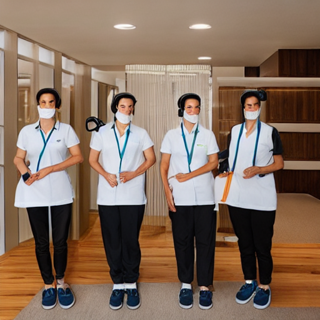

In [ ]:
spec = PROMPT_SPECS[0]
SEED = 42
res_obj = run_initial(spec["prompt"])
attrs = list(dict.fromkeys(t for t, _ in spec["pairs"]))

P, pmasks = binding_matrix(res_obj, spec["prompt"], txt2img.tokenizer, attrs)
if P is None:
    print("No people detected -- lower score_thresh or check the image.")
else:
    peaks = [phrase_peak(res_obj.attn, txt2img.tokenizer, spec["prompt"], a) for a in attrs]
    df, summary = score_binding(P, attrs, peaks)
    print(pd.DataFrame(P, columns=attrs, index=[f"person_{i}" for i in range(len(P))]).round(3))
    print()
    print(df.round(3))
    print()
    print(summary)
    display(res_obj.image.resize((320, 320)))

          red apron  yellow helmet
person_0      0.455          0.606
person_1      0.545          0.394


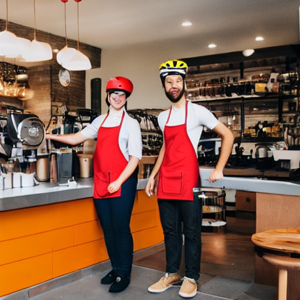

In [ ]:
SEED = 42
p2 = "a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet"
r2 = run_initial(p2)
attrs2 = ["red apron", "yellow helmet"]
P2, _ = binding_matrix(r2, p2, txt2img.tokenizer, attrs2, n_people=2)
print(pd.DataFrame(P2, columns=attrs2, index=[f"person_{i}" for i in range(len(P2))]).round(3))
display(r2.image.resize((300, 300)))

In [ ]:
all_bind, all_summary = [], []
for seed in (42, 7):
    SEED = seed
    for spec in PROMPT_SPECS:
        attrs = list(dict.fromkeys(t for t, _ in spec["pairs"]))
        r_ = run_initial(spec["prompt"])
        P, _ = binding_matrix(r_, spec["prompt"], txt2img.tokenizer, attrs)
        if P is None:
            print("no people:", spec["item_index"], seed); continue
        peaks = [phrase_peak(r_.attn, txt2img.tokenizer, spec["prompt"], a) for a in attrs]
        df, summary = score_binding(P, attrs, peaks)
        df["item_index"], df["seed"] = spec["item_index"], seed
        all_bind.append(df)
        all_summary.append(dict(item_index=spec["item_index"], seed=seed, **summary))
        print("done", spec["item_index"], seed)

bind_df = pd.concat(all_bind, ignore_index=True)
bind_df.to_csv("ssa_binding_results.csv", index=False)
sum_df = pd.DataFrame(all_summary)
print(sum_df)
print("\ninjective rate:", sum_df["injective"].mean().round(3))
print(bind_df.groupby("attribute")[["concentration", "decisiveness", "peak_share"]].mean().round(3))

KeyboardInterrupt: 

In [ ]:
import itertools
attrs = ["tote bag", "mustache", "water bottle", "headphones"]
maps = {a: phrase_attention(res_obj.attn, txt2img.tokenizer, spec["prompt"], a) for a in attrs}
for a, b in itertools.combinations(attrs, 2):
    print(f"{a:14s} vs {b:14s}  r={np.corrcoef(maps[a].ravel(), maps[b].ravel())[0,1]:+.3f}")

tote bag       vs mustache        r=+0.482
tote bag       vs water bottle    r=+0.789
tote bag       vs headphones      r=+0.305
mustache       vs water bottle    r=+0.620
mustache       vs headphones      r=+0.750
water bottle   vs headphones      r=+0.508


          red apron  yellow helmet
person_0      0.455          0.606
person_1      0.545          0.394


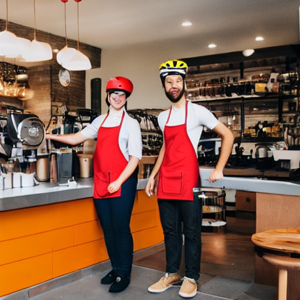

In [ ]:
SEED = 42
p2 = "a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet"
r2 = run_initial(p2)
attrs2 = ["red apron", "yellow helmet"]
P2, _ = binding_matrix(r2, p2, txt2img.tokenizer, attrs2, n_people=2)
print(pd.DataFrame(P2, columns=attrs2, index=[f"person_{i}" for i in range(len(P2))]).round(3))
display(r2.image.resize((300, 300)))

In [ ]:
import itertools

MECHANISM_PROMPTS = [
    dict(n=2, prompt="a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet",
         pairs=[("barista","red apron","torso"), ("cyclist","yellow helmet","head")]),
    dict(n=2, prompt="a photo of a chef wearing a white hat and a farmer holding a shovel",
         pairs=[("chef","white hat","head"), ("farmer","shovel","hands")]),
    dict(n=2, prompt="a photo of a nurse wearing blue gloves and a pilot wearing dark sunglasses",
         pairs=[("nurse","blue gloves","hands"), ("pilot","dark sunglasses","head")]),

    dict(n=3, prompt="a photo of a barista wearing a red apron, a cyclist wearing a yellow helmet, and a chef holding a pan",
         pairs=[("barista","red apron","torso"), ("cyclist","yellow helmet","head"), ("chef","pan","hands")]),
    dict(n=3, prompt="a photo of a chef wearing a white hat, a farmer holding a shovel, and a nurse wearing blue gloves",
         pairs=[("chef","white hat","head"), ("farmer","shovel","hands"), ("nurse","blue gloves","hands")]),
    dict(n=3, prompt="a photo of a pilot wearing dark sunglasses, a teacher holding a book, and a barista wearing a red apron",
         pairs=[("pilot","dark sunglasses","head"), ("teacher","book","hands"), ("barista","red apron","torso")]),

    dict(n=4, prompt="a photo of a barista wearing a red apron, a cyclist wearing a yellow helmet, a chef wearing a white hat, and a farmer holding a shovel",
         pairs=[("barista","red apron","torso"), ("cyclist","yellow helmet","head"), ("chef","white hat","head"), ("farmer","shovel","hands")]),
    dict(n=4, prompt="a photo of a nurse wearing blue gloves, a pilot wearing dark sunglasses, a chef holding a pan, and a teacher holding a book",
         pairs=[("nurse","blue gloves","hands"), ("pilot","dark sunglasses","head"), ("chef","pan","hands"), ("teacher","book","hands")]),
    dict(n=4, prompt="a photo of a farmer holding a shovel, a barista wearing a red apron, a cyclist wearing a yellow helmet, and a nurse wearing blue gloves",
         pairs=[("farmer","shovel","hands"), ("barista","red apron","torso"), ("cyclist","yellow helmet","head"), ("nurse","blue gloves","hands")]),
]

def phrase_person_dist(result, prompt, tokenizer, phrase, pmasks):
    A = phrase_attention(result.attn, tokenizer, prompt, phrase)
    v = np.array([float((A * w).max()) for w in pmasks])
    return v / (v.sum() + 1e-8)

def run_mechanism(spec, seed):
    global SEED
    SEED = seed
    res = run_initial(spec["prompt"])
    pmasks = person_masks(res.image, max_people=spec["n"])
    K = len(pmasks)
    if K != spec["n"]:
        return None, K
    bind, maps, regions = [], {}, {}
    for subj, attr, region in spec["pairs"]:
        ds = phrase_person_dist(res, spec["prompt"], txt2img.tokenizer, subj, pmasks)
        da = phrase_person_dist(res, spec["prompt"], txt2img.tokenizer, attr, pmasks)
        bind.append(dict(n=spec["n"], seed=seed, subject=subj, attribute=attr, region=region,
                         subj_person=int(ds.argmax()), attr_person=int(da.argmax()),
                         match=int(ds.argmax() == da.argmax()), attr_conc=float(da.max())))
        maps[attr] = phrase_attention(res.attn, txt2img.tokenizer, spec["prompt"], attr)
        regions[attr] = region
    corr = [dict(n=spec["n"], seed=seed, a=a, b=b,
                 same_region=int(regions[a] == regions[b]),
                 r=float(np.corrcoef(maps[a].ravel(), maps[b].ravel())[0, 1]))
            for a, b in itertools.combinations(maps, 2)]
    return (bind, corr), K
print("ready")

ready


In [ ]:
bind_rows, corr_rows, skipped = [], [], []
for seed in (42, 7):
    for spec in MECHANISM_PROMPTS:
        out, K = run_mechanism(spec, seed)
        if out is None:
            skipped.append((spec["n"], seed, spec["prompt"][:35], K))
            print(f"SKIP n={spec['n']} seed={seed}: detected {K} people"); continue
        b, c = out
        bind_rows += b; corr_rows += c
        print(f"done n={spec['n']} seed={seed}")

bind_df, corr_df = pd.DataFrame(bind_rows), pd.DataFrame(corr_rows)
bind_df.to_csv("mechanism_binding.csv", index=False)
corr_df.to_csv("mechanism_corr.csv", index=False)
print(f"\n{len(bind_df)} bindings, {len(corr_df)} pairs, {len(skipped)} prompts skipped")

done n=2 seed=42
done n=2 seed=42
done n=2 seed=42
SKIP n=3 seed=42: detected 2 people
done n=3 seed=42
done n=3 seed=42
SKIP n=4 seed=42: detected 3 people
done n=4 seed=42
done n=4 seed=42
done n=2 seed=7
done n=2 seed=7
done n=2 seed=7
done n=3 seed=7
done n=3 seed=7
done n=3 seed=7
SKIP n=4 seed=7: detected 3 people
SKIP n=4 seed=7: detected 3 people
done n=4 seed=7

39 bindings, 39 pairs, 4 prompts skipped


In [ ]:
print("=== BINDING ACCURACY vs CHANCE ===")
acc = bind_df.groupby("n")["match"].agg(["mean", "count"])
acc["chance"] = 1.0 / acc.index
acc["lift"] = acc["mean"] - acc["chance"]
print(acc.round(3))

print("\n=== MAP CORRELATION: same body region vs different ===")
print(corr_df.groupby("same_region")["r"].agg(["mean", "std", "count"]).round(3))
print("\nby subject count:")
print(corr_df.groupby(["n", "same_region"])["r"].mean().unstack().round(3))

=== BINDING ACCURACY vs CHANCE ===
    mean  count  chance   lift
n                             
2  0.417     12   0.500 -0.083
3  0.267     15   0.333 -0.067
4  0.500     12   0.250  0.250

=== MAP CORRELATION: same body region vs different ===
              mean    std  count
same_region                     
0            0.195  0.241     32
1            0.229  0.262      7

by subject count:
same_region      0      1
n                        
2            0.104    NaN
3            0.128  0.198
4            0.303  0.241


In [ ]:
print(bind_df.groupby("n")["attr_conc"].mean().round(3))
print("chance:", {2: 0.500, 3: 0.333, 4: 0.250})

n
2    0.587
3    0.513
4    0.399
Name: attr_conc, dtype: float64
chance: {2: 0.5, 3: 0.333, 4: 0.25}


In [ ]:
def run_mechanism2(spec, seed):
    global SEED
    SEED = seed
    res = run_initial(spec["prompt"])
    pmasks = person_masks(res.image, max_people=spec["n"])
    if len(pmasks) != spec["n"]:
        return None
    rows = []
    for subj, attr, region in spec["pairs"]:
        ds = phrase_person_dist(res, spec["prompt"], txt2img.tokenizer, subj, pmasks)
        da = phrase_person_dist(res, spec["prompt"], txt2img.tokenizer, attr, pmasks)
        rows.append(dict(n=spec["n"], seed=seed, subject=subj, attribute=attr,
                         subj_conc=float(ds.max()), attr_conc=float(da.max()),
                         subj_person=int(ds.argmax()), attr_person=int(da.argmax()),
                         match=int(ds.argmax() == da.argmax())))
    return rows

rows2 = []
for seed in (42, 7):
    for spec in MECHANISM_PROMPTS:
        out = run_mechanism2(spec, seed)
        if out: rows2 += out
m2 = pd.DataFrame(rows2)

print(m2.groupby("n")[["subj_conc", "attr_conc"]].mean().round(3))
print("chance:", {2: 0.500, 3: 0.333, 4: 0.250})
print("\nsubject nouns landing on distinct people, per prompt:")
print(m2.groupby(["n", "seed"]).apply(
    lambda g: g["subj_person"].nunique() == len(g)).groupby("n").mean().round(3))

   subj_conc  attr_conc
n                      
2      0.592      0.587
3      0.464      0.513
4      0.364      0.399
chance: {2: 0.5, 3: 0.333, 4: 0.25}

subject nouns landing on distinct people, per prompt:
n
2    0.0
3    0.0
4    0.0
dtype: float64


/tmp/ipykernel_566/1758670414.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(m2.groupby(["n", "seed"]).apply(


In [ ]:
from transformers import CLIPProcessor, CLIPModel
from scipy.optimize import linear_sum_assignment

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

@torch.no_grad()
def person_masks_boxes(image, max_people=4, score_thresh=0.7, res=ATTN_RES):
    t = TF.to_tensor(image).to(DEVICE)
    out = detector([t])[0]
    keep = (out["labels"] == COCO_PERSON) & (out["scores"] >= score_thresh)
    masks, boxes, scores = out["masks"][keep][:, 0], out["boxes"][keep], out["scores"][keep]
    if masks.shape[0] == 0:
        return np.zeros((0, res, res), np.float32), []
    order = scores.argsort(descending=True)[:max_people]
    small = F.interpolate(masks[order][:, None].float(), size=(res, res), mode="area")[:, 0]
    return small.cpu().numpy(), boxes[order].cpu().numpy().tolist()

@torch.no_grad()
def assign_subjects(image, boxes, subject_names):
    """Hungarian match detected people -> subject nouns using CLIP. Returns {subject: person_idx}."""
    crops = [image.crop(tuple(b)) for b in boxes]
    inp = clip_proc(text=[f"a photo of a {s}" for s in subject_names],
                    images=crops, return_tensors="pt", padding=True).to(DEVICE)
    sim = clip_model(**inp).logits_per_image.softmax(-1).cpu().numpy()   # (people, subjects)
    r, c = linear_sum_assignment(-sim)
    return {subject_names[j]: int(i) for i, j in zip(r, c)}

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

detected: 2 expected: 2
assignment: {'barista': 0, 'cyclist': 1}
--- CLIP says person_0 is the barista ---


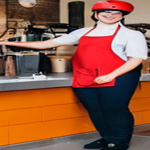

--- CLIP says person_1 is the cyclist ---


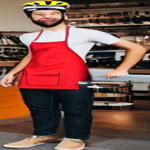

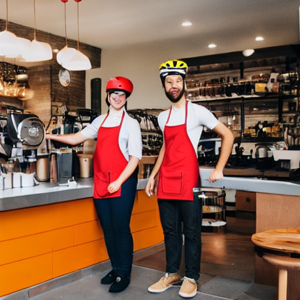

In [ ]:
SEED = 42
spec = MECHANISM_PROMPTS[0]
res = run_initial(spec["prompt"])
pmasks, boxes = person_masks_boxes(res.image, max_people=spec["n"])
subjects = [s for s, _, _ in spec["pairs"]]
print("detected:", len(pmasks), "expected:", spec["n"])

if len(pmasks) == spec["n"]:
    assign = assign_subjects(res.image, boxes, subjects)
    print("assignment:", assign)
    for s, i in assign.items():
        print(f"--- CLIP says person_{i} is the {s} ---")
        display(res.image.crop(tuple(boxes[i])).resize((150, 150)))
display(res.image.resize((300, 300)))

In [ ]:
crops = [res.image.crop(tuple(b)) for b in boxes]
inp = clip_proc(text=["a person wearing a red apron", "a person wearing a yellow helmet"],
                images=crops, return_tensors="pt", padding=True).to(DEVICE)
with torch.no_grad():
    sim = clip_model(**inp).logits_per_image.softmax(-1).cpu().numpy()
print(pd.DataFrame(sim, columns=["red apron", "yellow helmet"],
                   index=[f"person_{i}" for i in range(len(crops))]).round(3))
print("subject assignment was:", assign)


          red apron  yellow helmet
person_0      0.975          0.025
person_1      0.876          0.124
person_2      0.950          0.050
person_3      0.349          0.651
subject assignment was: {'farmer': 0, 'barista': 1, 'cyclist': 2, 'nurse': 3}


          red apron  yellow helmet
person_0        1.0            0.0
person_1        1.0            0.0
subject assignment: {'barista': 0, 'cyclist': 1}
barista: assigned person_0 | attribute 'red apron' points to person_0
cyclist: assigned person_1 | attribute 'yellow helmet' points to person_1


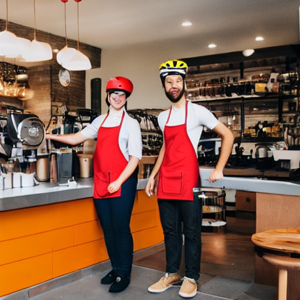

In [ ]:
SEED = 42
spec = MECHANISM_PROMPTS[0]
res = run_initial(spec["prompt"])
pmasks, boxes = person_masks_boxes(res.image, max_people=spec["n"])
subjects = [s for s, _, _ in spec["pairs"]]
attrs    = [a for _, a, _ in spec["pairs"]]
assign   = assign_subjects(res.image, boxes, subjects)
crops    = [res.image.crop(tuple(b)) for b in boxes]

inp = clip_proc(text=[f"a person wearing a {a}" for a in attrs],
                images=crops, return_tensors="pt", padding=True).to(DEVICE)
with torch.no_grad():
    sim = clip_model(**inp).logits_per_image.softmax(-1).cpu().numpy()

print(pd.DataFrame(sim, columns=attrs, index=[f"person_{i}" for i in range(len(crops))]).round(3))
print("subject assignment:", assign)
for (subj, attr, _), j in zip(spec["pairs"], range(len(attrs))):
    print(f"{subj}: assigned person_{assign[subj]} | attribute '{attr}' points to person_{int(sim[:, j].argmax())}")
display(res.image.resize((300, 300)))

In [ ]:
rows3, skipped3 = [], []
for seed in (42, 7):
    for spec in MECHANISM_PROMPTS:
        SEED = seed
        res = run_initial(spec["prompt"])
        pmasks, boxes = person_masks_boxes(res.image, max_people=spec["n"])
        if len(pmasks) != spec["n"]:
            skipped3.append((spec["n"], seed, len(pmasks))); continue
        subjects = [s for s, _, _ in spec["pairs"]]
        assign = assign_subjects(res.image, boxes, subjects)
        for subj, attr, region in spec["pairs"]:
            da = phrase_person_dist(res, spec["prompt"], txt2img.tokenizer, attr, pmasks)
            rows3.append(dict(n=spec["n"], seed=seed, subject=subj, attribute=attr, region=region,
                              gt_person=assign[subj], attr_person=int(da.argmax()),
                              match=int(int(da.argmax()) == assign[subj]),
                              attr_conc=float(da.max())))
        print(f"done n={spec['n']} seed={seed}")

m3 = pd.DataFrame(rows3)
m3.to_csv("mechanism_clip_gt.csv", index=False)
print(f"\n{len(m3)} bindings, {len(skipped3)} skipped: {skipped3}")

acc = m3.groupby("n")["match"].agg(["mean", "count"])
acc["chance"] = 1.0 / acc.index
acc["lift"] = acc["mean"] - acc["chance"]
print(acc.round(3))

done n=2 seed=42
done n=2 seed=42
done n=2 seed=42
done n=3 seed=42
done n=3 seed=42
done n=4 seed=42
done n=4 seed=42
done n=2 seed=7
done n=2 seed=7
done n=2 seed=7
done n=3 seed=7
done n=3 seed=7
done n=3 seed=7
done n=4 seed=7

39 bindings, 4 skipped: [(3, 42, 2), (4, 42, 3), (4, 7, 3), (4, 7, 3)]
    mean  count  chance   lift
n                             
2  0.333     12   0.500 -0.167
3  0.333     15   0.333  0.000
4  0.333     12   0.250  0.083


In [ ]:
from diffusers.models.attention_processor import AttnProcessor2_0
txt2img.unet.set_attn_processor(AttnProcessor2_0())   # drop capture hooks; faster

def generate(prompt, seed, steps=30, guidance=7.5):
    g = torch.Generator(DEVICE).manual_seed(seed)
    return txt2img(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=g).images[0]

@torch.no_grad()
def clip_attribute_matrix(image, boxes, attributes):
    crops = [image.crop(tuple(b)) for b in boxes]
    texts = [f"a photo of a person with a {a}" for a in attributes]
    inp = clip_proc(text=texts, images=crops, return_tensors="pt", padding=True).to(DEVICE)
    out = clip_model(**inp)
    per_person = out.logits_per_image.softmax(-1).cpu().numpy()  # (people, attrs): what each person wears
    per_attr   = out.logits_per_text.softmax(-1).cpu().numpy()   # (attrs, people): where each attr lives
    return per_person, per_attr
print("ready")

ready


In [ ]:
leak_rows, count_rows = [], []
for seed in (42, 7, 123):
    for spec in MECHANISM_PROMPTS:
        img = generate(spec["prompt"], seed)
        _, boxes = person_masks_boxes(img, max_people=spec["n"])
        attrs = [a for _, a, _ in spec["pairs"]]
        count_rows.append(dict(n=spec["n"], seed=seed, detected=len(boxes),
                               correct_count=int(len(boxes) == spec["n"])))
        if len(boxes) < 2:
            continue
        per_person, per_attr = clip_attribute_matrix(img, boxes, attrs)
        claims = per_person.argmax(axis=1)          # each person's top attribute
        tops   = per_attr.argmax(axis=1)            # each attribute's top person
        for j, a in enumerate(attrs):
            leak_rows.append(dict(
                n=spec["n"], seed=seed, attribute=a,
                concentration=float(per_attr[j].max()), chance=1.0 / len(boxes),
                n_claiming=int((claims == j).sum()),      # >1 = leaked, 0 = absent
                detected=len(boxes)))
        leak_rows[-1]["exclusive"] = int(len(set(tops.tolist())) == len(attrs))
        print(f"done n={spec['n']} seed={seed} detected={len(boxes)}")

leak_df, count_df = pd.DataFrame(leak_rows), pd.DataFrame(count_rows)
leak_df.to_csv("leakage_results.csv", index=False)
count_df.to_csv("person_count.csv", index=False)
print(f"\n{len(leak_df)} attribute observations")

done n=2 seed=42 detected=2
done n=2 seed=42 detected=2
done n=2 seed=42 detected=2
done n=3 seed=42 detected=2
done n=3 seed=42 detected=3
done n=3 seed=42 detected=3
done n=4 seed=42 detected=3
done n=4 seed=42 detected=4
done n=4 seed=42 detected=4
done n=2 seed=7 detected=2
done n=2 seed=7 detected=2
done n=2 seed=7 detected=2
done n=3 seed=7 detected=3
done n=3 seed=7 detected=3
done n=3 seed=7 detected=3
done n=4 seed=7 detected=3
done n=4 seed=7 detected=3
done n=4 seed=7 detected=4
done n=2 seed=123 detected=2
done n=2 seed=123 detected=2
done n=2 seed=123 detected=2
done n=3 seed=123 detected=2
done n=3 seed=123 detected=3
done n=3 seed=123 detected=3
done n=4 seed=123 detected=4
done n=4 seed=123 detected=3
done n=4 seed=123 detected=4

81 attribute observations


In [ ]:
print("=== did the model draw the right number of people? ===")
print(count_df.groupby("n")[["correct_count"]].mean().round(3))

print("\n=== attribute localization (concentration vs chance) ===")
loc = leak_df.groupby("n")[["concentration", "chance"]].mean()
loc["lift"] = loc["concentration"] - loc["chance"]
print(loc.round(3))

print("\n=== leakage / neglect breakdown ===")
leak_df["outcome"] = leak_df["n_claiming"].map(lambda c: "absent" if c == 0 else ("exclusive" if c == 1 else "leaked"))
print(leak_df.groupby(["n", "outcome"]).size().unstack(fill_value=0))

=== did the model draw the right number of people? ===
   correct_count
n               
2          1.000
3          0.778
4          0.556

=== attribute localization (concentration vs chance) ===
   concentration  chance   lift
n                              
2          0.827   0.500  0.327
3          0.678   0.370  0.307
4          0.736   0.287  0.449

=== leakage / neglect breakdown ===
outcome  absent  exclusive  leaked
n                                 
2             7          4       7
3            16          2       9
4            19          7      10


          red apron  yellow helmet
person_0      1.000          0.131
person_1      0.998          0.036


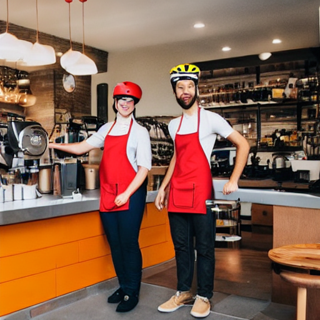

In [ ]:
@torch.no_grad()
def attribute_presence(image, boxes, attributes):
    """Independent presence per (person, attribute): specific caption vs generic."""
    crops = [image.crop(tuple(b)) for b in boxes]
    P = np.zeros((len(crops), len(attributes)))
    for j, a in enumerate(attributes):
        inp = clip_proc(text=[f"a photo of a person with a {a}", "a photo of a person"],
                        images=crops, return_tensors="pt", padding=True).to(DEVICE)
        P[:, j] = clip_model(**inp).logits_per_image.softmax(-1).cpu().numpy()[:, 0]
    return P

spec = MECHANISM_PROMPTS[0]
img = generate(spec["prompt"], 42)
_, boxes = person_masks_boxes(img, max_people=2)
attrs = [a for _, a, _ in spec["pairs"]]
P = attribute_presence(img, boxes, attrs)
print(pd.DataFrame(P, columns=attrs, index=[f"person_{i}" for i in range(len(boxes))]).round(3))
display(img.resize((320, 320)))

--- a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet
          red apron  yellow helmet
person_0        1.0            0.0
person_1        1.0            0.0


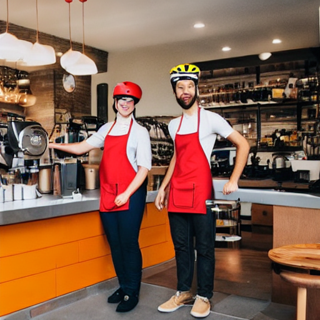

--- a photo of a chef wearing a white hat and a farmer holding a shovel
          white hat  shovel
person_0      0.968   0.032
person_1      0.550   0.450


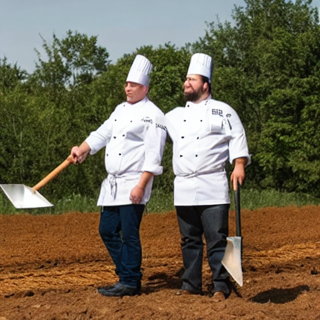

--- a photo of a nurse wearing blue gloves and a pilot wearing dark sunglasses
          blue gloves  dark sunglasses
person_0        0.634            0.366
person_1        0.231            0.769


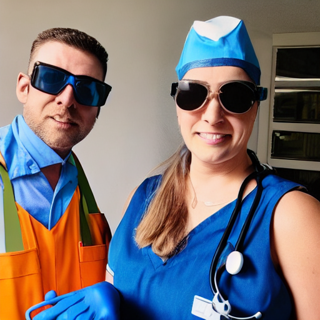

In [ ]:
for spec in MECHANISM_PROMPTS[:3]:          # the three 2-subject prompts
    img = generate(spec["prompt"], 42)
    _, boxes = person_masks_boxes(img, max_people=spec["n"])
    attrs = [a for _, a, _ in spec["pairs"]]
    if len(boxes) < 2:
        print("skip, detected", len(boxes)); continue
    per_person, _ = clip_attribute_matrix(img, boxes, attrs)
    print("---", spec["prompt"])
    print(pd.DataFrame(per_person, columns=attrs,
                       index=[f"person_{i}" for i in range(len(boxes))]).round(3))
    display(img.resize((320, 320)))

In [ ]:
leak_rows, count_rows = [], []
for seed in (42, 7, 123, 5, 17, 88, 200, 314, 999):
    for spec in MECHANISM_PROMPTS:
        img = generate(spec["prompt"], seed)
        _, boxes = person_masks_boxes(img, max_people=spec["n"])
        attrs = [a for _, a, _ in spec["pairs"]]
        count_rows.append(dict(n=spec["n"], seed=seed, detected=len(boxes),
                               correct_count=int(len(boxes) == spec["n"])))
        if len(boxes) < 2:
            continue
        per_person, per_attr = clip_attribute_matrix(img, boxes, attrs)
        claims = per_person.argmax(axis=1)
        bijection = int(len(set(claims.tolist())) == len(boxes))
        for j, a in enumerate(attrs):
            leak_rows.append(dict(n=spec["n"], seed=seed, attribute=a,
                                  concentration=float(per_attr[j].max()),
                                  chance=1.0 / len(boxes),
                                  n_claiming=int((claims == j).sum()),
                                  detected=len(boxes), bijection=bijection))
    print("seed done:", seed)

leak_df, count_df = pd.DataFrame(leak_rows), pd.DataFrame(count_rows)
leak_df.to_csv("leakage_results_full.csv", index=False)
count_df.to_csv("person_count_full.csv", index=False)

print("\n=== people drawn correctly ===")
print(count_df.groupby("n")["correct_count"].agg(["mean", "count"]).round(3))
print("\n=== images where every person got a distinct attribute ===")
print(leak_df.groupby(["n", "seed"])["bijection"].first().groupby("n").agg(["mean", "count"]).round(3))
print("\n=== attribute outcome ===")
leak_df["outcome"] = leak_df["n_claiming"].map(lambda c: "absent" if c == 0 else ("exclusive" if c == 1 else "leaked"))
print(leak_df.groupby(["n", "outcome"]).size().unstack(fill_value=0))

In [ ]:
ATTN_RES = 32          # was 16; SD1.5 exposes cross-attn at 64/32/16/8

class AttentionStore:
    def __init__(self, cond_index, num_chunks, attn_res=ATTN_RES):
        self.cond_index, self.num_chunks = cond_index, num_chunks
        self.n_positions, self.res = attn_res * attn_res, attn_res
        self.steps, self._sum, self._count = [], None, 0
    def record(self, probs, heads):
        if probs.shape[1] != self.n_positions:
            return
        m = probs[self.cond_index * heads:(self.cond_index + 1) * heads].mean(0).float()
        self._sum = m if self._sum is None else self._sum + m
        self._count += 1
    def next_step(self):
        if self._count:
            self.steps.append((self._sum / self._count).cpu().numpy())
        self._sum, self._count = None, 0
    def finalize(self):
        self.next_step()
        assert self.steps, "no attention captured -- check ATTN_RES matches a real UNet resolution"
        return np.stack(self.steps)          # (T, hw, 77)

def run_initial(prompt, steps=30, guidance=7.5, attn_res=ATTN_RES):
    store = AttentionStore(cond_index=1, num_chunks=2, attn_res=attn_res)
    install_capture(txt2img.unet, store)
    def _cb(pipe, i, t, kw):
        store.next_step(); return kw
    g = torch.Generator(DEVICE).manual_seed(SEED)
    img = txt2img(prompt, num_inference_steps=steps, guidance_scale=guidance,
                  generator=g, callback_on_step_end=_cb).images[0]
    return StepResult(img, store.finalize())

def phrase_attention(attn, tokenizer, prompt, phrase, res=ATTN_RES, t_lo=0.0, t_hi=0.5):
    """t_lo/t_hi select a fraction of the denoising trajectory. Default = first half,
    where layout is decided (Attend-and-Excite intervenes there, not at the end)."""
    idx = token_indices(tokenizer, prompt, phrase)
    T = attn.shape[0]
    lo, hi = int(T * t_lo), max(int(T * t_hi), int(T * t_lo) + 1)
    m = attn[lo:hi][:, :, idx].mean(axis=(0, 2)).reshape(res, res)
    return (m - m.min()) / (m.max() - m.min() + 1e-8)
print("F1 ready — ATTN_RES =", ATTN_RES)

F1 ready — ATTN_RES = 32


In [ ]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection
owl_proc  = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
owl_model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32").to(DEVICE).eval()

@torch.no_grad()
def owl_detect(image, queries, threshold=0.08):
    inp = owl_proc(text=[queries], images=image, return_tensors="pt").to(DEVICE)
    out = owl_model(**inp)
    tgt = torch.tensor([[image.size[1], image.size[0]]], device=DEVICE)
    r = owl_proc.post_process_object_detection(out, threshold=threshold, target_sizes=tgt)[0]
    return [dict(box=[float(x) for x in b], score=float(s), label=queries[int(l)])
            for b, s, l in zip(r["boxes"], r["scores"], r["labels"])]

def _center(b): return ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)
def _contains(pb, pt): return pb[0] <= pt[0] <= pb[2] and pb[1] <= pt[1] <= pb[3]

# Calibrated on the barista/cyclist pilot image: the true "yellow helmet" hit
# scored 0.183 (as three near-duplicate boxes on the same true detection --
# OWL-ViT doesn't run NMS across separate query calls); a false positive (the
# barista's cap misread as "a yellow helmet") scored 0.126. 0.14 sits between
# them. This is a single-image calibration -- the validation cell below
# re-runs it on two more prompts to check it doesn't also drop a legitimate
# low-salience detection elsewhere.
ATTR_OWNERSHIP_THRESHOLD = 0.14

def pixel_ground_truth(image, attributes, n_expected, ownership_threshold=ATTR_OWNERSHIP_THRESHOLD):
    """Locate people and attributes in pixels; assign each attribute to the person
    containing it. Returns (person_boxes, {attr: [person_idx,...]}, gate_status)."""
    people = sorted(owl_detect(image, ["a person"], 0.12), key=lambda d: -d["score"])[:n_expected]
    pboxes = [p["box"] for p in people]
    if len(pboxes) != n_expected:
        return pboxes, {}, f"person_count={len(pboxes)}"
    owner = {}
    for a in attributes:
        # Raw OWL-ViT threshold stays low so every candidate box is visible.
        dets = owl_detect(image, [f"a {a}"], 0.08)
        # Collapse to one score per person -- the max over any box whose
        # center falls inside that person's box -- then gate on the
        # calibrated ownership threshold, not the raw detection threshold.
        # This is what rejects a low-confidence misread while keeping a
        # confident true hit on the person actually wearing/holding it.
        best_per_person = {}
        for d in dets:
            for i, pb in enumerate(pboxes):
                if _contains(pb, _center(d["box"])):
                    best_per_person[i] = max(best_per_person.get(i, 0.0), d["score"])
        owner[a] = sorted(i for i, score in best_per_person.items() if score >= ownership_threshold)
    missing = [a for a, o in owner.items() if not o]
    leaked  = [a for a, o in owner.items() if len(o) > 1]
    status = ("ok" if not missing and not leaked
              else f"missing={missing} leaked={leaked}")
    return pboxes, owner, status
print("F2 ready (pixel_ground_truth: per-person max-score + calibrated ownership threshold)")


attn shape (T, hw, 77): (31, 1024, 77) | expect hw = 1024
people: 2 | owners: {'red apron': [0, 1], 'yellow helmet': [0, 1]} | gate: missing=[] leaked=['red apron', 'yellow helmet']
red apron: attention map (32, 32), peak at (np.int64(16), np.int64(11))
yellow helmet: attention map (32, 32), peak at (np.int64(28), np.int64(1))


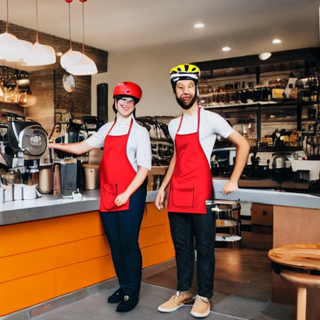

In [ ]:
SEED = 42
p = "a photo of a barista wearing a red apron and a cyclist wearing a yellow helmet"
r = run_initial(p)
print("attn shape (T, hw, 77):", r.attn.shape, "| expect hw =", ATTN_RES**2)

attrs = ["red apron", "yellow helmet"]
pboxes, owner, status = pixel_ground_truth(r.image, attrs, 2)
print("people:", len(pboxes), "| owners:", owner, "| gate:", status)

for a in attrs:
    A = phrase_attention(r.attn, txt2img.tokenizer, p, a)
    print(f"{a}: attention map {A.shape}, peak at {np.unravel_index(A.argmax(), A.shape)}")
display(r.image.resize((320, 320)))

In [ ]:
# Validate the calibrated ownership threshold (0.14): re-run the same
# barista/cyclist prompt that showed the leak, plus two more 2-subject
# prompts from MECHANISM_PROMPTS, to check the threshold rejects the false
# positive without also dropping a legitimate low-salience detection.
# Expect: "yellow helmet" now resolves to a single owner instead of both;
# "red apron" stays shared across both people (that one's correct ground
# truth, not a leak -- both people really do wear red aprons in the image).
for spec in MECHANISM_PROMPTS[:3]:
    attrs = [pair[1] for pair in spec["pairs"]]
    res = run_initial(spec["prompt"])
    pboxes, owner, status = pixel_ground_truth(res.image, attrs, spec["n"])
    print(f"--- {spec['prompt']}")
    print(f"    owners={owner} | gate={status}")


In [ ]:
@torch.no_grad()
def owl_detect(image, queries, threshold=0.08):
    inp = owl_proc(text=[queries], images=image, return_tensors="pt").to(DEVICE)
    out = owl_model(**inp)
    tgt = torch.tensor([[image.size[1], image.size[0]]], device=DEVICE)
    r = owl_model.post_process_object_detection(out, threshold=threshold, target_sizes=tgt)[0]
    return [dict(box=[float(x) for x in b], score=float(s), label=queries[int(l)])
            for b, s, l in zip(r["boxes"], r["scores"], r["labels"])]

In [ ]:
people_boxes = owl_detect(r.image, ["a person"], 0.1)
helmet_boxes = owl_detect(r.image, ["a yellow helmet"], 0.05)
print("people:", people_boxes)
print("yellow helmet:", helmet_boxes)

people: [{'box': [244.83816528320312, 102.38569641113281, 397.8659973144531, 510.69464111328125], 'score': 0.4269656538963318, 'label': 'a person'}, {'box': [83.5748062133789, 130.32777404785156, 244.99221801757812, 503.783447265625], 'score': 0.4202713966369629, 'label': 'a person'}]
yellow helmet: [{'box': [271.6222839355469, 99.11480712890625, 321.6669616699219, 130.92689514160156], 'score': 0.18321584165096283, 'label': 'a yellow helmet'}, {'box': [270.5749206542969, 99.90815734863281, 320.1483459472656, 176.4528045654297], 'score': 0.056251175701618195, 'label': 'a yellow helmet'}, {'box': [177.11856079101562, 128.9445343017578, 227.27273559570312, 186.9069366455078], 'score': 0.06914356350898743, 'label': 'a yellow helmet'}, {'box': [178.1924591064453, 129.0281219482422, 227.9485626220703, 171.5257110595703], 'score': 0.12631259858608246, 'label': 'a yellow helmet'}, {'box': [271.260986328125, 103.33317565917969, 321.4947509765625, 174.11875915527344], 'score': 0.0719619914889335

In [ ]:
import transformers
print("transformers version:", transformers.__version__)
print()
print("on owl_proc:          ", [m for m in dir(owl_proc) if "post_process" in m.lower()])
print("on owl_proc.image_processor:",
      [m for m in dir(owl_proc.image_processor) if "post_process" in m.lower()]
      if hasattr(owl_proc, "image_processor") else "no image_processor attribute")
print("on owl_model:          ", [m for m in dir(owl_model) if "post_process" in m.lower()])

transformers version: 5.13.1

on owl_proc:           ['post_process', 'post_process_grounded_object_detection', 'post_process_image_guided_detection', 'post_process_image_text_to_text', 'post_process_multimodal_output']
on owl_proc.image_processor: ['post_process_image_guided_detection', 'post_process_object_detection']
on owl_model:           []


In [ ]:
@torch.no_grad()
def owl_detect(image, queries, threshold=0.08):
    inp = owl_proc(text=[queries], images=image, return_tensors="pt").to(DEVICE)
    out = owl_model(**inp)
    tgt = torch.tensor([[image.size[1], image.size[0]]], device=DEVICE)
    r_out = owl_proc.image_processor.post_process_object_detection(out, threshold=threshold, target_sizes=tgt)[0]
    return [dict(box=[float(x) for x in b], score=float(s), label=queries[int(l)])
            for b, s, l in zip(r_out["boxes"], r_out["scores"], r_out["labels"])]

test = owl_detect(r.image, ["a person"], 0.12)
print("image size (w,h):", r.image.size)
print("detections:", test)

image size (w,h): (512, 512)
detections: [{'box': [244.83816528320312, 102.38569641113281, 397.8659973144531, 510.69464111328125], 'score': 0.4269656538963318, 'label': 'a person'}, {'box': [83.5748062133789, 130.32777404785156, 244.99221801757812, 503.783447265625], 'score': 0.4202713966369629, 'label': 'a person'}]
